In [ ]:
import tensorflow as tf
import keras

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)


TensorFlow version: 2.18.0
Keras version: 3.8.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/Datasets/Copy of devnagari digit.zip'
extract_to = '/content/drive/MyDrive/Datasets/devnagari_digits'  # output folder

os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("ZIP file extracted to:", extract_to)


✅ ZIP file extracted to: /content/drive/MyDrive/Datasets/devnagari_digits


Training set: (17000, 28, 28, 1), Labels: (17000, 10)
Testing set: (3000, 28, 28, 1), Labels: (3000, 10)


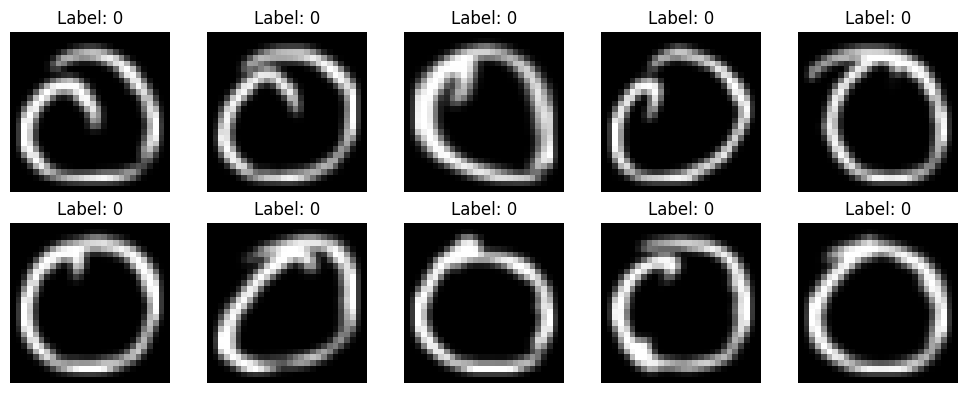

In [ ]:

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image  # PIL for image loading

train_dir = '/content/drive/MyDrive/Datasets/devnagari_digits/DevanagariHandwrittenDigitDataset/Train'
test_dir  = '/content/drive/MyDrive/Datasets/devnagari_digits/DevanagariHandwrittenDigitDataset/Test'


img_height, img_width = 28, 28

#Load images using PIL
def load_images_from_folder(folder):
    images = []
    labels = []
    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            img = Image.open(img_path).convert("L")  # Convert to grayscale
            img = img.resize((img_width, img_height))
            img = np.array(img) / 255.0
            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)


# Load and preprocess data
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

# Reshape for Keras
x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encoding
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Dataset summary
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")

# Visualize samples
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# Model parameters
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
num_classes = 10
input_shape = (28, 28, 1)
model = keras.Sequential(
[
keras.layers.Input(shape=input_shape),
keras.layers.Flatten(), # Flatten the 28x28 image to a 784-dimensional vector
keras.layers.Dense(64, activation="sigmoid"),
keras.layers.Dense(128, activation="sigmoid"),
keras.layers.Dense(256, activation="sigmoid"),
keras.layers.Dense(num_classes, activation="softmax"),
]
)

In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",  # Correct loss function for one-hot encoded labels
    metrics=["accuracy"]
)

In [ ]:
# Define training parameters
batch_size = 128
epochs = 20

# Define callbacks to save best model and prevent overfitting
callbacks = [
    keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=4),
]

# Train the model with validation split and callbacks
history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.2733 - loss: 1.9879 - val_accuracy: 0.0000e+00 - val_loss: 7.2731
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8263 - loss: 0.6396 - val_accuracy: 0.0000e+00 - val_loss: 9.1136
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9187 - loss: 0.2946 - val_accuracy: 0.0000e+00 - val_loss: 9.8496
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9438 - loss: 0.2013 - val_accuracy: 0.0000e+00 - val_loss: 10.3642
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9545 - loss: 0.1601 - val_accuracy: 0.0000e+00 - val_loss: 10.7860


In [ ]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=1)

# Print evaluation results
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9404 - loss: 0.3983
Test Loss: 2.2807
Test Accuracy: 0.7637


In [ ]:
# Save the model in .h5 format
model.save("devanagari_digit_recognition.h5")
print("Model saved successfully in .h5 format!")


Model saved successfully in .h5 format!


In [ ]:
from tensorflow.keras.models import load_model

# Load the model
loaded_model = load_model("devanagari_digit_recognition.h5")
print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
# Evaluate the loaded model on the test set
test_loss, test_accuracy = loaded_model.evaluate(x_test, y_test, verbose=1)

# Print results
print(f"Loaded Model Test Loss: {test_loss:.4f}")
print(f"Loaded Model Test Accuracy: {test_accuracy:.4f}")


94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9404 - loss: 0.3983
Loaded Model Test Loss: 2.2807
Loaded Model Test Accuracy: 0.7637


In [ ]:
# Make predictions on the test set
predictions = model.predict(x_test)

# Print the first 5 predictions
print("Predictions on first 5 test images:")
print(predictions[:5])  # Predicted probabilities


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predictions on first 5 test images:
[[9.9576187e-01 6.2311458e-04 1.2619099e-04 6.5747014e-07 9.0568738e-06
  1.4260071e-07 1.3883638e-03 2.0878145e-03 1.1858277e-06 1.6157029e-06]
 [9.9673015e-01 1.7781570e-03 4.7293208e-05 1.2446721e-07 2.6626543e-05
  7.1064299e-08 7.6413894e-04 6.5180619e-04 6.1492193e-07 8.8798561e-07]
 [9.9601460e-01 2.5744978e-03 1.0403419e-04 1.8317056e-07 3.5283483e-05
  8.9606338e-08 6.5203686e-04 6.1736436e-04 7.3507789e-07 1.1104606e-06]
 [9.9727988e-01 1.5786875e-03 8.8830777e-05 1.6989597e-07 1.6144149e-05
  5.2900333e-08 5.2304228e-04 5.1163812e-04 5.7002450e-07 8.6501336e-07]
 [9.9770993e-01 9.3350752e-04 5.8061134e-05 1.4672455e-07 1.7870934e-05
  8.5753939e-08 4.3079327e-04 8.4810995e-04 5.8193291e-07 8.5379662e-07]]


In [ ]:
# Convert predicted probabilities to digit labels
predicted_labels = np.argmax(predictions, axis=1)

# Print the predicted labels for the first 5 test images
print("Predicted labels for the first 5 test images:")
print(predicted_labels[:5])


Predicted labels for the first 5 test images:
[0 0 0 0 0]


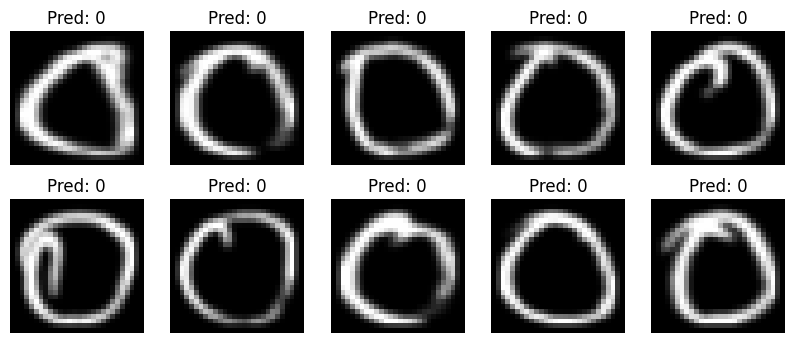

In [ ]:
# Visualize the first 10 test images along with their predicted labels
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {predicted_labels[i]}")
    plt.axis("off")

plt.show()


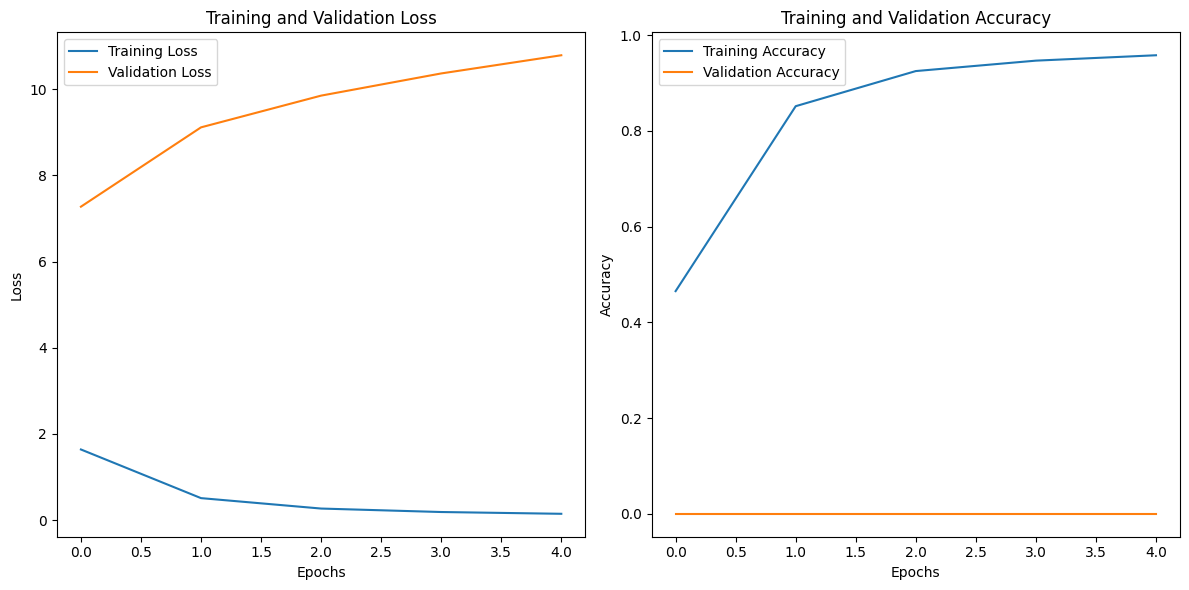

In [ ]:
# Plot the training and validation loss
plt.figure(figsize=(12, 6))

# Training loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot the training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()
